<img src="../img/iEEG_data_release_header.svg" width=1400 />

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cogitate-consortium/iEEG-data-release/blob/dev/notebooks/ieeg-data-release.ipynb)

# Using the COGITATE iEEG data 
Welcome to the COGITATE Consortium's iEEG Data Exploration Notebook! In this tutorial, we will guide you through the process of accessing and analyzing intracranial electroencephalography (iEEG) data collected as part of our consortium. The COGITATE consortium is an adversarial collaboration ([Melloni et al., 2023](#References), [COGITATE et al., 2023](#References)) aiming to deepen our understanding of consciousness by comparing two prominent theories: Integrated Information Theory (IIT) ([Albantakis et al., 2023](#References)) and Global Neuronal Workspace (GNW) ([Mashour et al., 2020](#References)).

The dataset we are sharing originates from experiments employing a carefully designed paradigm. Participants were presented with images from four distinct categories (faces, objects, letters and symbols), each displayed at three different orientations (center, left, and right). Furthermore, these images were shown for varying durations of 0.5, 1.0, and 1.5 seconds. At the beginning of each experimental block, participants were shown two specific target identities, representing either a specific face and a specific object. Participants were tasked with pressing a button when these target identities appeared. This introduced an additional task relevance condition: stimuli of the same category as the targets but of a different identity were deemed task-relevant, while stimuli from other categories were considered task-irrelevant. This comprehensive experimental design allows us to delve into the neural correlates of consciousness across different stimuli and temporal conditions while controlling for task demands (for more details, see [Melloni et al., 2023](#References)).

This notebook serves a dual purpose: to provide a user-friendly guide on how to navigate, load, preprocess, and access specific data within our dataset, and to introduce the basics of iEEG data analysis. We will walk you through a simple univariate analysis, offering insights into individual channels, and a basic multivariate analysis, shedding light on the complex interplay of neural signals.


In [1]:
# Authors: Alex Lepauvre <alex.lepauvre@gmail.com>
#
# License: MIT-License

In [2]:
%%capture
# Installing the toolbox if not found
try:
    import cog_ieeg
    print("cog_ieeg is already installed")
except ImportError:
    print("cog_ieeg is not installed. Installing now")
    %pip install git+https://github.com/Cogitate-consortium/iEEG-data-release.git@main#egg=cog_ieeg

In [3]:
# Setting all modules:
from pathlib import Path
import mne
import json
from mne.viz import plot_alignment, snapshot_brain_montage
from mne_bids import BIDSPath, read_raw_bids
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pingouin import ttest

from cog_ieeg.utils import (get_bids_root, get_fs_directory, set_bids_root, get_pipeline_config, 
                            create_default_config, set_xnat_host, set_xnat_project, print_config)
from cog_ieeg.xnat_utilities import xnat_download
from cog_ieeg.localization import get_roi_channels, create_montage
from cog_ieeg.vizualization import get_cmap_rgb_values, plot_ieeg_image

from cog_ieeg.pipelines import run_preprocessing, run_onset_responsiveness, run_decoding


# use mne-python's fsaverage data
mne.datasets.fetch_fsaverage(subjects_dir=get_fs_directory(), verbose=True)  # downloads if needed

0 files missing from root.txt in C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\fs
0 files missing from bem.txt in C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\fs\fsaverage
0 files missing from root.txt in C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\fs
0 files missing from bem.txt in C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\fs\fsaverage


'C:\\Users\\alexander.lepauvre\\Documents\\COGITATE\\bids\\derivatives\\fs\\fsaverage'

## Learning objectives
By the end of this tutorial, you will:

- Understand how to load and preprocess iEEG data from the COGITATE consortium
- Access and index specific data based on experimental conditions
- Perform a simple univariate analysis to examine the response patterns of individual channels
- Engage in a basic multivariate analysis to uncover relationships and patterns across multiple channels

<div class="alert alert-info"><h4>Note</h4><p> 
    This notebook does not aim to replicate the analysis of the COGITATE consortium analyses but rather guide users to use our data. The code to replicate the results will be shared <a href="url">here</a>.
</p></div>

## Set up and download of the BIDS converted data
When installing the cog_ieeg package, default paths are setup to store the data that we will soon download into. The default path is this on your local machine: 

In [4]:
print("bids root: ")
print("   {}".format(get_bids_root()))

bids root: 
   C:\Users\alexander.lepauvre\Documents\COGITATE\bids


This is the default path where the bids ieeg data will be downloaded. If you wish to change this default, you can do so easily using this command:

In [5]:
set_bids_root('YOUR/CUSTOM/PATH')
print("bids root: ")
print("   {}".format(get_bids_root()))

bids root: 
   YOUR/CUSTOM/PATH


The set_bids_root instantiates persistent changes, which means you only need to execute the above command once to change the default bids path. The change will remain except if you reinstall the package. You can also very easly reset to the default like so:

In [6]:
create_default_config()
print("bids root: ")
print("   {}".format(get_bids_root()))

bids root: 
   C:\Users\alexander.lepauvre\Documents\COGITATE\bids


Other than that, there are no setup step required, the data will be downloaded in the bids_root. The data can be downloaded in three different ways:

- raw data bundles
- raw data from XNAT
- bids converted data from XNAT

For the purpose of this notebook (and of this repository in general), we will work with the third option. With XNAT, we can download the data programatically from our servers, which enables to download one subject at a time as we need them. And the bids data are formated according to the bids [specifications](https://bids-specification.readthedocs.io/en/stable/). All the pipelines we are providing assume that the data are in bids, which has the nice conscequence that they should readily work on any data that are in the bids format without requiring any tweaking. 

To be able to download the data from XNAT, you first need to setup an account and agree to our terms and conditions, which you can do [here](https://www.arc-cogitate.com/data-release). You should now have a user name and a password. We provided functions that automatically download the data. You can either download the data one by one or download all the data we are sharing at once. 

To download one subject at a time, you can use the following function (note that the download will take some time, as a single subject is already 1Gb or more):

In [7]:
%%capture
# Example subject to download:
subject = 'CF102'
# Download the data of this subject
xnat_download('sub-' + subject, overwrite=False)
# xnat_download(None, ev.xnat_project, overwrite=True)

In the background, the xnat_download has been configured to access the data from the xnat host called https://cogitate-data.ae.mpg.de which stores all the data from the cogitate and from the project COG_IEEG_EXP1_BIDS, which stores specifically the iEEG data in the bids format. But note that in the COGITATE, we also collected MEG and fMRI data, which can be downloaded in the same way, though you would need to change the project to match that of the modality you would like to download. This can be done simply and permanently using a similar command to what we have used for setting the bids root:

In [8]:
set_xnat_host('cogitate-data')  # Change to another host if you like
set_xnat_project('COG_IEEG_EXP1_BIDS')   # Change to another project if you like

The overwrite flag of the xnat_download specifies whether or not the data should be downloaded again if they are already on you computer. If you pass None for subjects, the function will download all the data at once. We recommend you to first play around with a couple of subjects, because the whole data set is quite heavy and takes some time to download. You can also pass a list of subjects to download several in one go.
 Also note that we are showing this to illustrate how that would work. But we also implemented automatic download in the preprocessing so that if you try to run the preprocessing pipeline with a specific subject that isn't already downloaded, it will be downloaded automatically before the preprocessing starts

Now let's have a quick look at the data we have downloaded. Following the bids convention, the data are stored by session, data type and task. In the data we have released so far, data were collected within 1 session. The task was called Dur and we are of course interested in iEEG data. So we can specify all of that and use the mne_bids functions to locate and download the data:

In [9]:
%%capture
# bids path parameters:
session = "1"
datatype = "ieeg"
task = "Dur"

# Create the mne bids path object, making access to the data easier. We will use one example subject to demonstrate the details of our analyses. 
bids_path = BIDSPath(root=get_bids_root(), subject=subject,
                     session=session,
                     datatype=datatype,
                     task=task)
raw = read_raw_bids(bids_path=bids_path, verbose=True);

Let's now have a look at the info and plot the power spectrum density:

<Info | 11 non-empty values
 bads: []
 ch_names: G1, G2, G3, G4, G5, G6, G7, G8, G9, G10, G11, G12, G13, G14, ...
 chs: 110 ECoG, 24 sEEG, 2 ECG
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 134 items (134 EEG)
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 lowpass: 1024.0 Hz
 meas_date: 2000-01-01 00:00:00 UTC
 nchan: 136
 projs: []
 sfreq: 2048.0 Hz
 subject_info: 8 items (dict)
>
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


C:\Users\alexander.lepauvre\AppData\Local\Temp\ipykernel_31264\4120576344.py:2: FutureWarning: The value of `amplitude='auto'` will be removed in MNE 1.8.0, and the new default will be `amplitude=False`.
  raw.plot_psd()
c:\Users\alexander.lepauvre\Documents\GitHub\iEEG-data-release\.venv\Lib\site-packages\mne\viz\utils.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


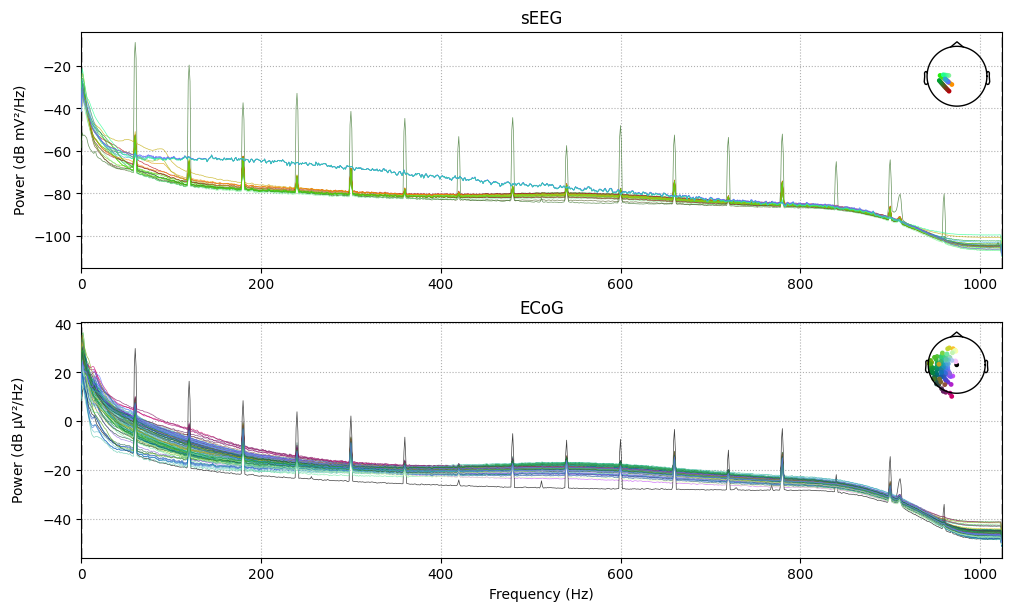

In [10]:
print(raw.info)
raw.plot_psd()
plt.show()

## The Preprocessing pipeline

### The default config
The BIDS downloaded data can then be preprocessed. The various pipelines illustrated in this notebook have many parameters. Default parameters are stored in json files within the cog_ieeg package. These can accessed easily using the functions called get_pipeline_config, specifying the name of the pipeline you would like to run:


In [11]:
param = get_pipeline_config('preprocessing')
print_config(param)

Configuration content:

{
    "session": "1",
    "task": "Dur",
    "data_type": "ieeg",
    "downsample_rate": 512,
    "njobs": 4,
    "save_intermediary_steps": false,
    "check_plots": false,
    "plot_single_channels": false,
    "preprocessing_steps": [
        "plot_channels_loc",
        "description_bad_channels_rejection",
        "notch_filtering",
        "laplace_reference",
        "hg_computations",
        "erp_computations",
        "epoching"
    ],
    "plot_channels_loc": {
        "broadband": {
            "channel_types": {
                "ecog": true,
                "seeg": true,
                "exclude": "bads"
            }
        }
    },
    "atlas_mapping": {
        "broadband": {
            "copy_recon": true,
            "recon_source": "{0}/{0}_ECOG_V1/RESOURCES/ElecRecon/fs_recon/{0}",
            "list_parcellations": [
                "aparc+aseg",
                "aparc.a2009s+aseg"
            ],
            "remove_channels_unknown": true
 

The config consists of a dictionary specifying a sequential list of steps to apply, as well as the option to use for each of these steps. The default parameters are the same as we used in the cogitate study:
- Removal of bad channels 
- Notch filtering to remove line noise (60Hz)
- Re-referencing using Laplace scheme
- High gamma computations (70-150Hz)
- ERP computations (0-30Hz)
- Epoching

The dictionary that we have previously loaded can be passed to the function called run_preprocessing, which will apply all these steps to a particular subject (or list of subjects). So for example, with the default preprocessing configuration, we will apply the notch filter with these parameters:

In [12]:
print_config(param["notch_filtering"])

Configuration content:

{
    "broadband": {
        "channel_types": {
            "ecog": true,
            "seeg": true,
            "exclude": "bads"
        },
        "frequency": 60,
        "remove_harmonics": true,
        "filter_type": "fir",
        "cutoff_lowpass_bw": 63,
        "cutoff_highpass_bw": 57
    }
}


The 'broadband' key specifies which signal on which the filtering should be applied (in this case the non-filtered raw data, i.e. the broadband signal). Within this dictionary, the channel_types key specifies which type of channels the filtering should be applied. The frequency specifies the frequency that should be notched out, and so on. In the folder called docs, you can find a json file called preprocessing_config-doc.json describing the various parameters that can be changed and what they mean. Alternatively, you can also load the documented config to read the parameters:

In [13]:
param = get_pipeline_config('preprocessing-doc')
print_config(param["notch_filtering"])

Configuration content:

{
    "broadband_comment": "Signal on which to apply filtering. Broadband specifies that this should be applied on the raw data. The notch filtering should in most cases be applied to the raw signal, prior to any frequency computations",
    "broadband": {
        "channel_types_comment": "channels on which to apply the notch filtering",
        "channel_types": {
            "ecog": true,
            "seeg": true,
            "exclude": "bads"
        },
        "frequency_comment": "Frequency to remove (in Hz)",
        "frequency": 60,
        "remove_harmonics_comment": "If true, removing harmonics from 60 to Nyquist frequency (120Hz, 180Hz...)",
        "remove_harmonics": true,
        "filter_type_comment": "Filter type to use. Default is FIR, other option is butterworth_4o",
        "filter_type": "fir",
        "cutoff_lowpass_bw_comment": "Low pass bandwidth. Only use for butterworth_4o",
        "cutoff_lowpass_bw": 63,
        "cutoff_highpass_bw_com

You can also change the default parameters of the preprocessing pipeline. Say you collected your data in Europe, in which case the line noise frequency is not 60Hz but 50Hz instead. You can load the default and adjust teh notch frequency, like so:

In [14]:
# Loading the parameters:
param = get_pipeline_config('preprocessing')

# Adjust the filtering frequency to 50Hz
param["notch_filtering"]["broadband"]["frequency"] = 50
print("New filtering frequency: ")
print_config(param["notch_filtering"])

New filtering frequency: 
Configuration content:

{
    "broadband": {
        "channel_types": {
            "ecog": true,
            "seeg": true,
            "exclude": "bads"
        },
        "frequency": 50,
        "remove_harmonics": true,
        "filter_type": "fir",
        "cutoff_lowpass_bw": 63,
        "cutoff_highpass_bw": 57
    }
}


In addition, you might not want to apply the laplace referencing step in your case, you can simply remove it from the list steps to be executed:

In [15]:
# Remove the laplace reference step:
param["preprocessing_steps"].remove("laplace_reference")

Alternatively, you can also create your own custom json file. That way, you can change many parameters manually and use them to run the preprocessing pipeline. For that, you should go to the docs folder and check out the preprocessing_config-template.json. This file is basically a copy of the default parameters found in the toolbox. You can simply make a copy of it, adjust whichever parameters you want to adjust and then, you can run the preprocessing pipeline by passing the pass to your custom config file as the config argument (see below). It is also handy to do so to keep a copy of your custom parameters at hands. 

Note that as part of the preprocessing pipeline, the set of parameters that were used during the preprocessing are saved as a json file alongside the data that are produced. So if you are ever in doubt of which parameters were used, you can double check directly with the data. 

### Running the preprocessing pipeline
The preprocessing pipeline takes two inputs: 
- Parameters
- Subjects

As we have seen above, the parameters specifies all the parameters to control how the data are preprocessed. The run_preprocessing pipeline requires the parameters to be either the path to a json file or a dictionary. So you can either specify the path to the default configuration found in the cog_ieeg or the path to your custom parameters. Alternatively, you can also load the default parameters from the json and adjust a few parameters that you wish to change, and pass directly the dictionary as an input (as illustrated below). 

It further takes the subject ID on whom to run the preprocessing. You can either pass a string for running the preprocessing on a single subject or a list to run the preprocessing on several subjects. And as we have explained above, if you haven't downloaded the data already, the script will download the data before running. So if you wish to explore our dataset, you can simply run the script specifying a few different subjects which will all be downloaded as needed.

For the sake of speed, we will deactivate the option of plotting every single channel. It will take about 5min to run.

In [16]:
%%capture
# Loading the parameters:
param = get_pipeline_config('preprocessing')
param["check_plots"] = False
param["plot_single_channels"] = False
run_preprocessing(param, subject)

### Visualizing the preprocessed data
The final output of the preprocessing pipeline are the epoched data. The naming conventions of the folders follow the BIDS conventions
You can therefore load the data as follows, and plot a single channel using mne functionalities

Reading C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\preprocessing\sub-CF102\ses-1\ieeg\epoching\high_gamma\sub-CF102_ses-1_task-Dur_desc-epoching_ieeg-epo.fif ...


    Found the data of interest:
        t =    -750.00 ...    2500.00 ms
        0 CTF compensation matrices available
Adding metadata with 9 columns
1440 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1440 matching events found
No baseline correction applied
0 projection items activated


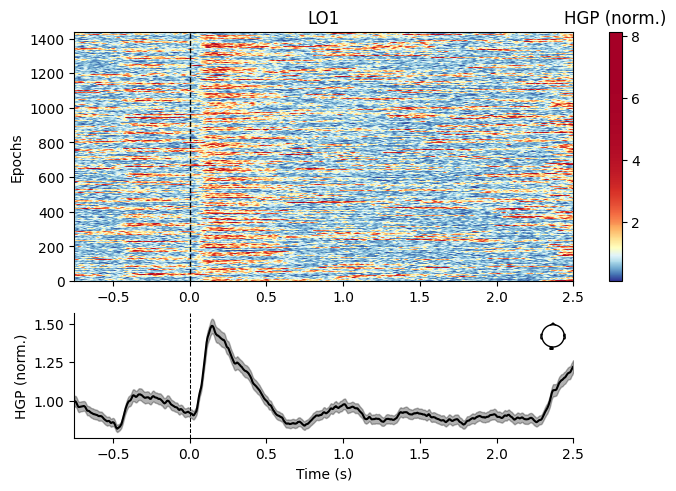

In [17]:
channel = 'LO1'
example_epochs_path = Path(get_bids_root(), 'derivatives', 'preprocessing',
                           'sub-' + subject, 'ses-' + session, 'ieeg',
                           "epoching", 'high_gamma',
                           "sub-{}_ses-{}_task-{}_desc-epoching_{}-epo.fif".format(subject,
                                                                                   session, task,
                                                                                   "ieeg"))

epochs = mne.read_epochs(example_epochs_path, preload=True)
plot_ieeg_image(epochs, channel, show=False, 
                units="HGP (norm.)", scalings=1, cmap="RdYlBu_r",
                center=None, ylim_prctile=None, logistic_cmap=True, ci=0.95)
plt.show()

Notice that the figure above looks odd, with some activation in the baseline. That is because we have data that are epochs relative to both the onset and the offset of the stimuli for different analyses. For most purpose, we would need to select only the epochs locked to stimulus onset. This can be achieved by selecting the epochs by conditions, like so:

Not setting metadata
720 matching events found
No baseline correction applied
0 projection items activated


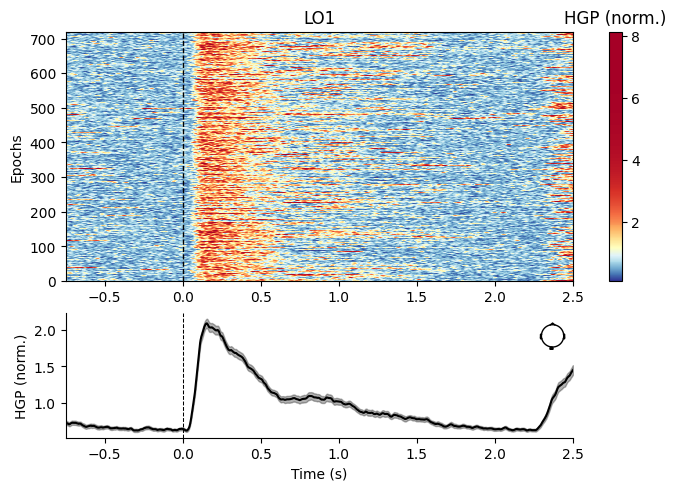

In [18]:
onset_locked_epochs = epochs['stimulus onset']
plot_ieeg_image(onset_locked_epochs, channel, show=False, 
                units="HGP (norm.)", scalings=1, cmap="RdYlBu_r",
                center=None, ylim_prctile=None, logistic_cmap=True, ci=0.95)
plt.show()

In general, if you wish to extract specific conditions, this data are equipped with forward slash separated strings, enabling you to select any condition by passing the according string or list of strings. Consult the documentation found in the file task-Dur_events_description.json to find all the conditions
that can be accessed from the data.

Not setting metadata
320 matching events found
No baseline correction applied
0 projection items activated


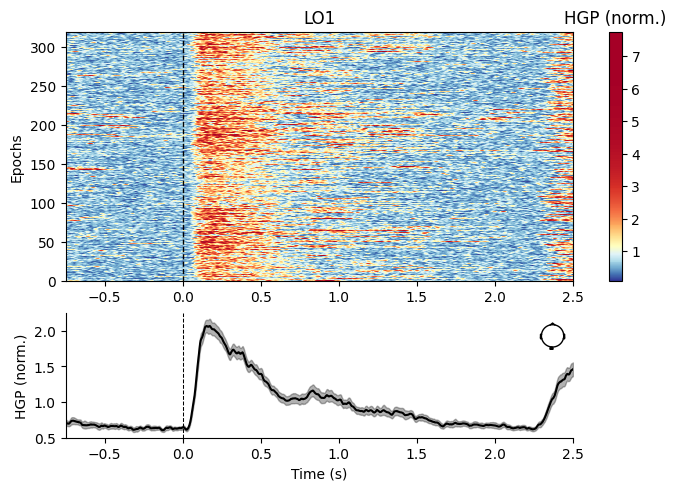

In [19]:
task_relevant_epochs = epochs['stimulus onset/Relevant non-target']
plot_ieeg_image(task_relevant_epochs, channel, show=False, 
                units="HGP (norm.)", scalings=1, cmap="RdYlBu_r",
                center=None, ylim_prctile=None, logistic_cmap=True, ci=0.95)
plt.show()

Not setting metadata
26 matching events found
No baseline correction applied
0 projection items activated


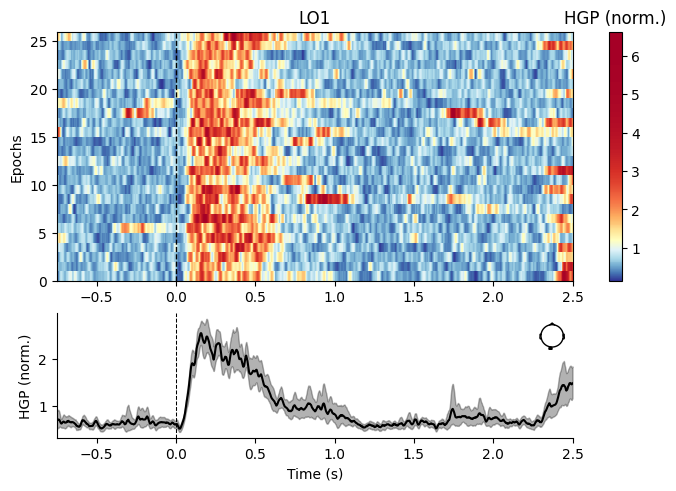

In [20]:
task_relevant_face_short_epochs = epochs['stimulus onset/Relevant non-target/face/500ms']
plot_ieeg_image(task_relevant_face_short_epochs, channel, show=False, 
                units="HGP (norm.)", scalings=1, cmap="RdYlBu_r",
                center=None, ylim_prctile=None, logistic_cmap=True, ci=0.95)
plt.show()


## Onset responsiveness
Now that the data were preprocessed, we can apply the onset responsiveness analysis, which consists in comparing single channel activation before and after visual stimuli onsets. This enables determining which are the channels which are responsive to our task in general. To do so, we will compute a Bayes factor using the JZS Bayes Factor approximation described in [SOURCE]. This method consists in computing a paired t-test and using a formula to generate a Bayes factor. The main advantage of this approach is that it alleviates the need for multiple comparison correction. This way, the results will not change as a function of the number of subjects that gets added. 

Practically, we will first extract the trials locked to the onset of the stimuli and remove the target trials (as these require participants responses). We will then extract the pre (-0.3 to 0 sec. from stimulus onset) and post-stimulus (0.05 to 0.35 sec.) presentation segments for each trial. The data within each segment will be aggregated by computing the area under the curve (np.trapz). Finally, we will use the pingouin function ttest with the Cauchy scale factor set to 0.707 (default value in pingouin). 

We will first show an example on a single channel then proceed to show how to run it on all electrodes of selected subjects.

T-test results:
   T-stat=-59.858
   p-value=0.0
   BF=9.324e+259
   df=639


C:\Users\alexander.lepauvre\AppData\Local\Temp\ipykernel_31264\3781591356.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  prestim_auc = np.trapz(prestim_data, axis=1)
C:\Users\alexander.lepauvre\AppData\Local\Temp\ipykernel_31264\3781591356.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  poststim_auc = np.trapz(poststim_data, axis=1)


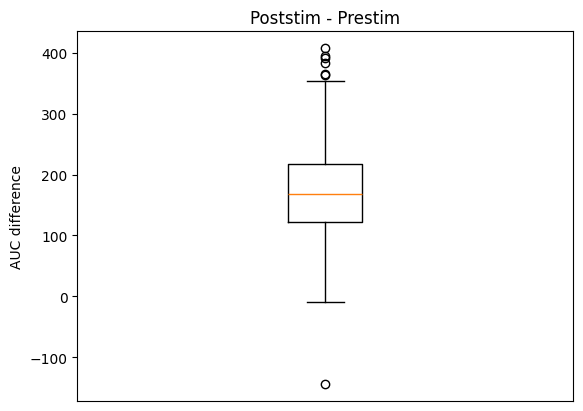

In [21]:
# Select the trials of interest:
onset_responsiveness_data =  epochs[["stimulus onset/Irrelevant", "stimulus onset/Relevant non-target"]]
# Crop the data:
prestim_data = np.squeeze(onset_responsiveness_data.copy().crop(tmin=-0.3, tmax=0).get_data(picks='LO1'))
poststim_data = np.squeeze(onset_responsiveness_data.copy().crop(tmin=0.05, tmax=0.350).get_data(picks='LO1'))
# Compute the AUC:
prestim_auc = np.trapz(prestim_data, axis=1)
poststim_auc = np.trapz(poststim_data, axis=1)
# Perform a two sided paired t-test:
results = ttest(prestim_auc, poststim_auc, paired=True, r=0.707, alternative='two-sided').round(3)

# Showing the results of the test:
print('T-test results:')
print('   T-stat={}'.format(results['T'].item()))
print('   p-value={}'.format(results['p-val'].item()))
print('   BF={}'.format(results['BF10'].item()))
print('   df={}'.format(results['dof'].item()))
fig, ax = plt.subplots()
ax.boxplot(poststim_auc - prestim_auc)
ax.set_title('Poststim - Prestim')
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_ylabel('AUC difference')
plt.show()


As we can see, the difference between pre and post-stimulus window is positive, indicating that HG activation is larger after stimulus onset. Accordingly, the bayes factor is really large, indicating that we have very strong evidence that this channel is responsive to our experimental paradigm.

### Onset responsiveness pipeline
The above example was applied to a single channel from a single participant. We further provide pipelines that enable the 
computation of onset responsiveness on all channels and subjects. As in the case of the preprocessing pipeline, this can
be achieved by calling the function onset_responsiveness which takes 3 mandatory inputs:
- config_file: a json file specifying the details of the analysis, such as the trials on which to apply the pipeline, pre and post stimuli time windows, metric to use...
- subject: a string or a list of the name of subjects on whom to apply the pipeline
- bids_root: path to the bids folder on the local drive.
Just as in the case of the pre-processing, the config files are highly configurable with many additional options. You can either load our default config using the get_pipeline_config('onset_responsiveness') or create your custom config by copying the files located in docs/onset_responsiveness_config-template.json

This function further takes two additional inputs:
- plot_single_channels: boolean flag to plot single electrodes or not
- plot_only_responsive: boolean flag to plot only those channels that were found to have differences in activation compared to baseline. 

Single channels plotting can take a long time, so you might want to deactivate it.

In [22]:
%%capture
config_file = param = get_pipeline_config('onset_responsiveness')
results = run_onset_responsiveness(config_file, subject, plot_single_channels=False, plot_only_responsive=False)

### Investigate the results
The pipeline generates a dataframe containing the results of the onset responsiveness test, with one row per channel, with the results of the test in the columns:
Now that we have ran the onset responsiveness analysis, we can provide some summary statistics for the 
data. 

In [23]:
print(results.head())

  subject   channel  statistic  pvalue            bf  reject     df  lowCI  \
0   CF102  CF102-G1      3.017   0.003  3.999000e+00    True  639.0   1.15   
1   CF102  CF102-G2      0.840   0.401  6.300000e-02   False  639.0  -1.27   
2   CF102  CF102-G3     -2.230   0.026  5.230000e-01   False  639.0  -4.76   
3   CF102  CF102-G4     -5.101   0.000  1.454000e+04    True  639.0  -7.35   
4   CF102  CF102-G5     -6.511   0.000  3.332000e+07    True  639.0  -7.76   

   highCI    f_size  
0    5.43 -0.119357  
1    3.18 -0.033211  
2   -0.30  0.088216  
3   -3.27  0.201812  
4   -4.17  0.257587  


We can investigate the results to assess how many electrodes show a change in activation, and for how many activation increases and decreases compared to the baseline period

In [24]:
# Channels counts:
responsive_channels = results[results['reject'] == True]
activated_channels = results[(results['reject'] == True) & (results['f_size'] > 0)]
deactivated_channels = results[(results['reject'] == True) & (results['f_size'] < 0)]
# Print the counts:
print("{} out of {} ({:.2f}%) were found to be onset responsive!".format(
    responsive_channels.shape[0], 
    results.shape[0],
    responsive_channels.shape[0] / results.shape[0] * 100))
print("{} out of {} ({:.2f}%) showed an increase of activation following  stimulus onset!".format(
    activated_channels.shape[0], 
    results.shape[0],
    activated_channels.shape[0] / results.shape[0] * 100
))
print("{} out of {} ({:.2f}%) showed an decrease of activation following  stimulus onset!".format(
    deactivated_channels.shape[0], 
    results.shape[0],
    deactivated_channels.shape[0] / results.shape[0] * 100
))

28 out of 92 (30.43%) were found to be onset responsive!
18 out of 92 (19.57%) showed an increase of activation following  stimulus onset!
10 out of 92 (10.87%) showed an decrease of activation following  stimulus onset!


### Plotting responsive channels on the brain surface
One important sanity check is to make sure that the localization of the effects make sense. As 
the task in the COGITATE was visual, one would expect to find a lot of onset responsive electrodes
over the posterior cortex. To check whether that is the case, we will extract only the onset responsive
electrodes that we hve identified above and we will plot that on the pial surface. 

This step require MNE setup to have been performed as to allow 3D rendering. Consult the MNE webpage: XXX

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Channel types::	ecog: 28
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


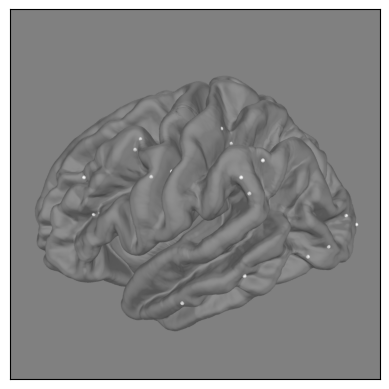

In [25]:
# Extract the onset responsive electrodes:
onset_responsive_results = results.loc[results["reject"] == True]
# Get these channels localization in MNI space:
mni_info = create_montage(onset_responsive_results["channel"].to_list(), bids_path, get_fs_directory())

# We can now go ahead and plot the ecog channels on the brain:
# Plot the ecog:
fig = plot_alignment(
    info=mni_info,
    trans="fsaverage",
    subject="fsaverage",
    subjects_dir=get_fs_directory(),
    surfaces=["pial"],
    coord_frame="head",
    ecog=True, 
    seeg=False,
    sensor_colors=[[1.0, 1.0, 1.0, 0.8]] * len(mni_info.ch_names),
)
mne.viz.set_3d_view(fig, azimuth=180, elevation=70, focalpoint="auto", distance=0.4)
xy, im = snapshot_brain_montage(fig, mni_info)
fig2, ax2 = plt.subplots()
ax2.imshow(im)
ax2.yaxis.set_visible(False)
ax2.xaxis.set_visible(False)
plt.show()
mne.viz.close_3d_figure(fig)


Additionally, not only do we expect more channels to be responsive in posterior regions, we also expect the effects to be stronger. To vizualize this, you can plot the effect sizes of the onset
responsiveness on the brain.

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Channel types::	ecog: 28
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


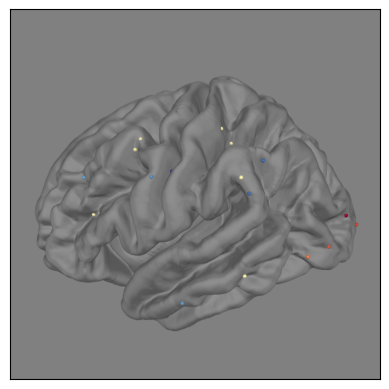

In [26]:
# Specifying the different views:
orientations = {
    "left": {"azimuth": 180, "elevation": None, "distance": 0.4, "focalpoint": "auto"},
    "front": {"azimuth": 90, "elevation": None, "distance": 0.4, "focalpoint": "auto"},
    "right": {"azimuth": 0, "elevation": None, "distance": 0.4, "focalpoint": "auto"},
    "back": {"azimuth": -90, "elevation": None, "distance": 0.4, "focalpoint": "auto"},
    "top": {"azimuth": 0, "elevation": 180, "distance": 0.4, "focalpoint": "auto"},
    "bottom": {"azimuth": 180, "elevation": 0, "distance": 0.4, "focalpoint": "auto"}
}

# Extract the effect sizes:
f_sizes = onset_responsive_results["f_size"].to_list()

# Get the RGB values for effect sizes mapped onto a colormap<
sensor_colors = get_cmap_rgb_values(f_sizes, cmap=None, center=0)

# We can now go ahead and plot the dig montage on the brain:
fig = plot_alignment(
    info=mni_info,
    trans="fsaverage",
    subject="fsaverage",
    subjects_dir=get_fs_directory(),
    surfaces=["pial"],
    coord_frame="head",
    ecog=True, 
    seeg=False,
    sensor_colors=sensor_colors,
)
mne.viz.set_3d_view(fig, azimuth=180, elevation=70, focalpoint="auto", distance=0.4)

xy, im = snapshot_brain_montage(fig, mni_info)
xy_pts = np.vstack([xy[ch] for ch in mni_info.ch_names])
fig2, ax2 = plt.subplots()
ax2.imshow(im)
ax2.yaxis.set_visible(False)
ax2.xaxis.set_visible(False)
plt.show()
mne.viz.close_3d_figure(fig)

The colorbar is centered on 0, such that channels showing an increase in effect size are plotted in yellow/red tones while the channels showing a decrease in activation are plotted in blueish tones. As is to be expected, the channels located in occipital regions show the strongest effect sizes, but onset responsive electrodes can be found in several cortical locations

### Investigate specific regions of interest
We further provide functionalities to extract channels located in specific regions of interest. This will be illustrated by extracting channels located within the visual cortex. We will extract all channels located within the G_cuneus, G_occipital_sup, G_occipital_sup, Pole_occipital, S_calcarine, S_oc_sup_and_transversal, S_oc_middle_and_Lunatus as defined by the Destrieux atlas.

The following channels were found in the ROI
['LO1', 'LO2', 'LO3', 'LO4', 'LO5']
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Channel types::	ecog: 5
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


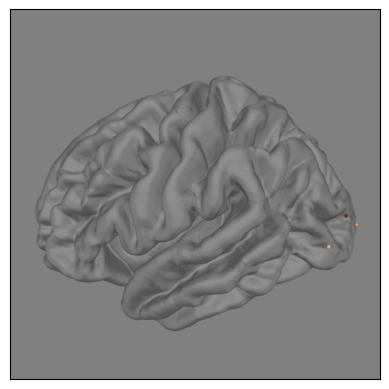

In [27]:
# Define the list of regions of interest:
rois = ["Pole_occipital",
        "G_occipital_middle",
        "G_cuneus",
       ]
# Extract the channels within this ROI:
roi_channels = get_roi_channels(epochs.ch_names, rois, bids_path, 'destrieux')
print('The following channels were found in the ROI')
print(roi_channels)
# Extract the onset responsiveness results for the channels only:
roi_onset_responsiveness = results.loc[results['channel'].isin(['-'.join([subject, channel]) for channel in roi_channels])]
channels_counts = roi_onset_responsiveness.groupby("reject").count().reset_index()[["reject", "channel"]]

# Create a montage for these channels alone:
roi_mni_info = create_montage(roi_onset_responsiveness["channel"].to_list(), bids_path, get_fs_directory())

# Extract the effect sizes:
roi_f_sizes = roi_onset_responsiveness["f_size"].to_list()

# Get the RGB values for effect sizes mapped onto a colormap
roi_sensor_colors = get_cmap_rgb_values(roi_f_sizes, cmap="Oranges", center=None)

# We can now go ahead and plot the dig montage on the brain:
fig = plot_alignment(
    info=roi_mni_info,
    trans="fsaverage",
    subject="fsaverage",
    subjects_dir=get_fs_directory(),
    surfaces=["pial"],
    coord_frame="head",
    ecog=True, 
    seeg=False,
    sensor_colors=roi_sensor_colors,
)
mne.viz.set_3d_view(fig, azimuth=180, elevation=70, focalpoint="auto", distance=0.4)

xy, im = snapshot_brain_montage(fig, roi_mni_info)
xy_pts = np.vstack([xy[ch] for ch in roi_mni_info.ch_names])
fig2, ax2 = plt.subplots()
ax2.imshow(im)
ax2.yaxis.set_visible(False)
ax2.xaxis.set_visible(False)
plt.show()
mne.viz.close_3d_figure(fig)

## Decoding
In addition to investigate the univariate responses of every single channel, we can also performed a multivariate analysis, investigating the presence of representation of particular contrasts of interests across the electrodes in our sample. In the current example, we will
use support vector machine to decode faces vs. objects across all electrodes within our example subject.

We will perform temporal generalization decoding using support vector machine for the faces vs objects labels in the task irrelevant trials. We will first prepare the data by selecting only seeg and ecog channels, downsample the data and select the conditions of interest. We will then create a classifier and apply it to our data with 5 fold cross validation and score the decoding accuracy using roc_auc. 

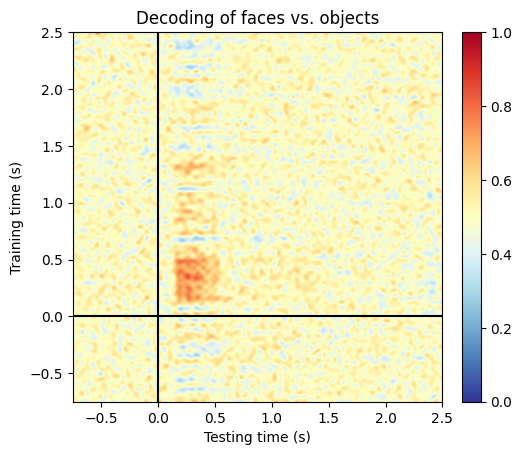

In [28]:
# Import the required libraries:
from sklearn.pipeline import make_pipeline
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from mne.decoding import (GeneralizingEstimator, cross_val_multiscore)


#Select electrodes:
picks = mne.pick_types(epochs.info, ecog=True, seeg=True)
decoding_epochs = epochs.copy().pick(picks)
# Downsample:
decoding_epochs.resample(30, n_jobs=1)
# Select trials:
decoding_epochs = decoding_epochs[["stimulus onset/Irrelevant/face", "stimulus onset/Irrelevant/object"]]

# Create the classifier:
clf_steps = []
clf_steps.append(StandardScaler())
clf_steps.append(svm.SVC(kernel='linear', class_weight='balanced'))
clf = make_pipeline(*clf_steps)
# Temporal generalization estimator:
time_gen = GeneralizingEstimator(clf, n_jobs=1, scoring='roc_auc',
                                 verbose="ERROR")

# Extract the data:
data = decoding_epochs.get_data()
# Get the classes:
y = decoding_epochs.metadata["category"].values
# Run the decoding:
scores = cross_val_multiscore(time_gen, data, y, cv=5, n_jobs=None)

# Plot the results:
fig, ax = plt.subplots()
# Plot matrix with transparency:
im = ax.imshow(np.mean(scores, axis=0), cmap="RdYlBu_r",
               extent=[epochs.times[0], epochs.times[-1], epochs.times[0], epochs.times[-1]],
               origin="lower",  # aspect="equal",
               interpolation="lanczos", vmin=0, vmax=1)
# Add the axis labels and so on:
ax.set_xlim([epochs.times[0], epochs.times[-1]])
ax.set_ylim([epochs.times[0], epochs.times[-1]])
ax.set_xlabel("Testing time (s)")
ax.set_ylabel("Training time (s)")
ax.set_title("Decoding of {}".format("faces vs. objects"))
ax.axvline(0, color='k')
ax.axhline(0, color='k')
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

### Decoding pipeline
The above example was applied to a single participant. We further provide pipelines to perform decoding on all subjects. Same deal as before, this can be achieved by calling the function decoding which takes 3 mandatory inputs:

- config_file: a json file specifying the details of the analysis, such as trials to select, decoding targets, cross task generalization...
- subjects_list: a list of the name of all the subjects on whom to apply the pipeline
- bids_root: path to the bids folder on the local drive. Just as in the case of the pre-processing, the config files are highly configurable with many additional options. Make sure to visit XXX to investigate these options and how to specify them.


In [29]:
config_file = get_pipeline_config('decoding')
scores = run_decoding(config_file, subject)

Welcome to Decoding!
The onset responsive channels of the following subjects will be determined: 
CF102
Decoding CF102
Reading C:\Users\alexander.lepauvre\Documents\COGITATE\bids\derivatives\preprocessing\sub-CF102\ses-1\ieeg\epoching\high_gamma\sub-CF102_ses-1_task-Dur_desc-epoching_ieeg-epo.fif ...
    Found the data of interest:
        t =    -750.00 ...    2500.00 ms
        0 CTF compensation matrices available
Adding metadata with 9 columns
1440 matching events found
No baseline correction applied
0 projection items activated
Decoding category with 5 folds stratified cross-validation:


### Decoding within regions of interest
In the case of decoding, it is especially relevant to be able to investigate spatial specificy. This can be achieved as shown in the onset responsiveness analysis by pre-selecting channels based on their anatomical labels. We will here show how to do so by selecting channels located within a posterior ROI defined by the following labels:



The following channels were found in the ROI
['LO1', 'LO2', 'LO3', 'LO4', 'LO5']


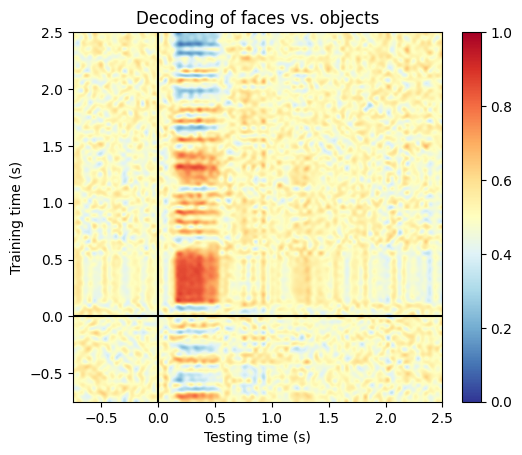

In [30]:
rois = ["Pole_occipital",
        "G_occipital_middle",
        "G_cuneus"]
# Extract the channels within this ROI:
roi_channels = get_roi_channels(epochs.ch_names, rois, bids_path, 'destrieux')
print('The following channels were found in the ROI')
print(roi_channels)

# Selecting those channels only:
roi_epochs = epochs.copy().pick(roi_channels)
# Downsample:
roi_epochs.resample(30, n_jobs=1)
# Select trials:
roi_epochs = roi_epochs[["stimulus onset/Irrelevant/face", "stimulus onset/Irrelevant/object"]]

# Create the classifier:
clf_steps = []
clf_steps.append(StandardScaler())
clf_steps.append(svm.SVC(kernel='linear', class_weight='balanced'))
clf = make_pipeline(*clf_steps)
# Temporal generalization estimator:
time_gen = GeneralizingEstimator(clf, n_jobs=1, scoring='roc_auc',
                                 verbose="ERROR")

# Extract the data:
data = roi_epochs.get_data()
# Get the classes:
y = roi_epochs.metadata["category"].values
# Run the decoding:
scores = cross_val_multiscore(time_gen, data, y, cv=5, n_jobs=None)

# Plot the results:
fig, ax = plt.subplots()
# Plot matrix with transparency:
im = ax.imshow(np.mean(scores, axis=0), cmap="RdYlBu_r",
               extent=[epochs.times[0], epochs.times[-1], epochs.times[0], epochs.times[-1]],
               origin="lower",  # aspect="equal",
               interpolation="lanczos", vmin=0, vmax=1)
# Add the axis labels and so on:
ax.set_xlim([epochs.times[0], epochs.times[-1]])
ax.set_ylim([epochs.times[0], epochs.times[-1]])
ax.set_xlabel("Testing time (s)")
ax.set_ylabel("Training time (s)")
ax.set_title("Decoding of {}".format("faces vs. objects"))
ax.axvline(0, color='k')
ax.axhline(0, color='k')
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

# References

- Melloni, L., Mudrik, L., Pitts, M., Bendtz, K., Ferrante, O., Gorska, U., ... & Tononi, G. (2023). An adversarial collaboration protocol for testing contrasting predictions of global neuronal workspace and integrated information theory. Plos one, 18(2), e0268577.

- Cogitate Consortium, Ferrante, O., Gorska-Klimowska, U., Henin, S., Hirschhorn, R., Khalaf, A., ... & Melloni, L. (2023). An adversarial collaboration to critically evaluate theories of consciousness. bioRxiv, 2023-06.

- Albantakis, L., Barbosa, L., Findlay, G., Grasso, M., Haun, A. M., Marshall, W., ... & Tononi, G. (2023). Integrated information theory (IIT) 4.0: formulating the properties of phenomenal existence in physical terms. PLoS Computational Biology, 19(10), e1011465.

- Mashour, G. A., Roelfsema, P., Changeux, J. P., & Dehaene, S. (2020). Conscious processing and the global neuronal workspace hypothesis. Neuron, 105(5), 776-798.

# Acknowledgments
This notebook is brought to you by the intracranial team of the COGITATE consortium.
<div style="display: flex; flex-wrap: wrap; justify-content: space-around;">
   <div style="text-align: center;">
      <a href="https://www.arc-cogitate.com/our-team" target="_blank">
         <img src="../img/IEEG TEAM.png" alt="iEEG team">
      </a>
   </div>
</div>
<br />
We would like to thank all the COGITATE consortium members:
<div style="display: flex; flex-wrap: wrap; justify-content: space-around;">
   <div style="text-align: center;">
      <a href="https://www.arc-cogitate.com/our-team" target="_blank">
         <img src="../img/IEEG DP Authors.png" alt="COGITATE team">
      </a>
   </div>
</div>
<img style="float: right;" src="../img/templeton_logo.png" width=200;>
<br />
<br />

This research was supported by Templeton World Charity Foundation ([TWCF0389](https://doi.org/10.54224/20389)) and the Max Planck Society. The opinions expressed in this publication are those of the authors and do not necessarily reflect the views of TWCF.
